# Free-Text House Price Estimator

**Xu Junjun · PE6201 End-of-Course Project**

## Problem and intended user

Home buyers and sellers may struggle to form a price expectation from property
details. This prototype accepts a free-text description of a house, extracts
seven property features with a foundation model, and estimates a sale price
using a trained regression model. It is a demonstration based on historical
Ames, Iowa sales, not a current professional valuation.

## Data and workflow

Data: Kaggle, *House Prices – Advanced Regression Techniques* (`train.csv`).
The 1,460 labelled rows are split into 80% training and 20% held-out testing.
Linear Regression is the baseline; Random Forest is compared on the same test
rows using RMSE. OpenRouter extracts features from text, while local rules
check missing, conflicting, and out-of-range values before prediction.

In [87]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Rows and columns:", df.shape)
print("Has SalePrice:", "SalePrice" in df.columns)
display(df.head())

Rows and columns: (1460, 81)
Has SalePrice: True


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [88]:
features = [
    "GrLivArea",    # 地上居住面积，平方英尺
    "OverallQual",  # 整体质量评分，1–10
    "YearBuilt",    # 建造年份
    "TotalBsmtSF",  # 地下室面积，平方英尺
    "FullBath",     # 完整浴室数量
    "BedroomAbvGr", # 地上卧室数量
    "GarageCars",   # 车库可停车辆数
]

display(df[features + ["SalePrice"]].head())
print("\nMissing values:")
print(df[features + ["SalePrice"]].isna().sum())
print("\nMean sale price: ${:,.0f}".format(df["SalePrice"].mean()))

,GrLivArea,OverallQual,YearBuilt,TotalBsmtSF,FullBath,BedroomAbvGr,GarageCars,SalePrice
0,1710,7,2003,856,2,3,2,208500
1,1262,6,1976,1262,2,3,2,181500
2,1786,7,2001,920,2,3,2,223500
3,1717,7,1915,756,1,3,3,140000
4,2198,8,2000,1145,2,4,3,250000



Missing values:
GrLivArea       0
OverallQual     0
YearBuilt       0
TotalBsmtSF     0
FullBath        0
BedroomAbvGr    0
GarageCars      0
SalePrice       0
dtype: int64

Mean sale price: $180,921


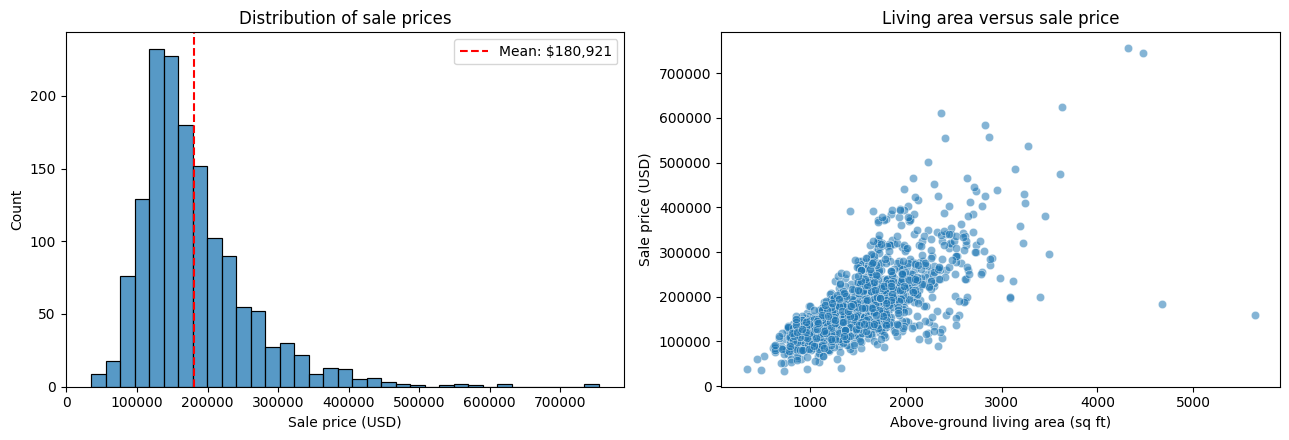

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["SalePrice"], bins=35, ax=axes[0])
axes[0].axvline(
    df["SalePrice"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: ${df['SalePrice'].mean():,.0f}",
)
axes[0].set_title("Distribution of sale prices")
axes[0].set_xlabel("Sale price (USD)")
axes[0].legend()

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice",
    alpha=0.55,
    ax=axes[1],
)
axes[1].set_title("Living area versus sale price")
axes[1].set_xlabel("Above-ground living area (sq ft)")
axes[1].set_ylabel("Sale price (USD)")

plt.tight_layout()
plt.show()

**EDA observation.** Sale prices are right-skewed: most homes are in the
lower-to-middle price range, while a small number of expensive sales extend
the right tail. Above-ground living area generally increases with sale price,
but several very large homes have unexpectedly low prices. These observations
motivate comparing a linear baseline with a non-linear model and examining
unusual prediction errors. The plots describe the dataset; they do not by
themselves establish that the model generalises to another housing market.

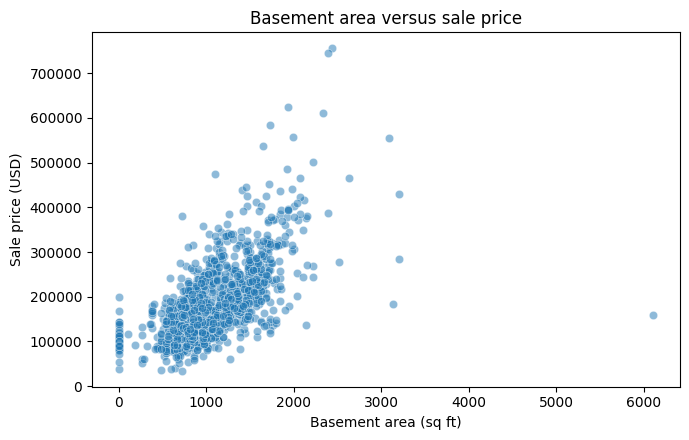

In [90]:
plt.figure(figsize=(7, 4.5))
sns.scatterplot(
    data=df,
    x="TotalBsmtSF",
    y="SalePrice",
    alpha=0.5,
)
plt.title("Basement area versus sale price")
plt.xlabel("Basement area (sq ft)")
plt.ylabel("Sale price (USD)")
plt.tight_layout()
plt.show()

**Basement-area observation.** Sale price generally increases with basement area, although homes with similar basement sizes can sell for very different prices. Homes without a basement appear at zero, and a few unusually large basements have comparatively low sale prices. These points are retained in the dataset; this plot alone does not establish that they are data errors.

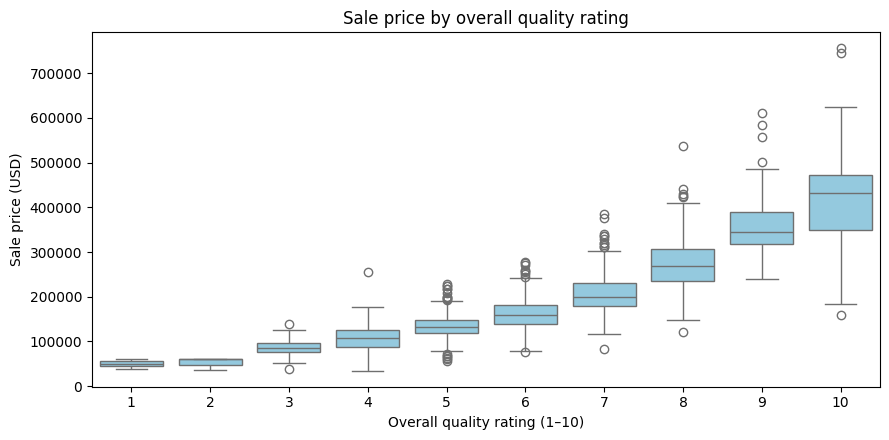

In [91]:
plt.figure(figsize=(9, 4.5))
sns.boxplot(
    data=df,
    x="OverallQual",
    y="SalePrice",
    color="skyblue",
)
plt.title("Sale price by overall quality rating")
plt.xlabel("Overall quality rating (1–10)")
plt.ylabel("Sale price (USD)")
plt.tight_layout()
plt.show()

**Quality-rating observation.** Median sale price generally rises as OverallQual increases from 1 to 10. Prices within each rating still vary, especially at higher ratings, so quality alone cannot determine a home's sale price. This relationship helps explain why OverallQual is useful to the model, while also making accurate extraction of the user's quality rating important.

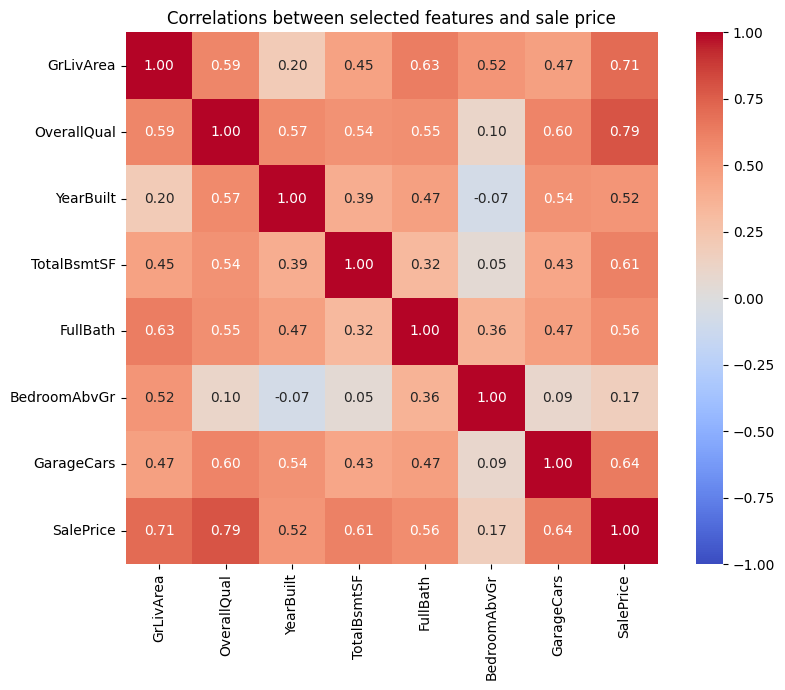

Correlation with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
TotalBsmtSF     0.613581
FullBath        0.560664
YearBuilt       0.522897
BedroomAbvGr    0.168213
Name: SalePrice, dtype: float64


In [92]:
correlations = df[features + ["SalePrice"]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Correlations between selected features and sale price")
plt.tight_layout()
plt.show()

print("Correlation with SalePrice:")
print(correlations["SalePrice"].drop("SalePrice").sort_values(ascending=False))

**Correlation observation.** Overall quality (0.79) and above-ground living
area (0.71) have the strongest positive linear correlations with sale price
among the selected inputs. Bedroom count has a much weaker correlation (0.17).
Several predictors also correlate with one another, so these values should
not be interpreted as independent causal effects. Correlation helps describe
the data, while held-out RMSE is used to compare predictive performance.

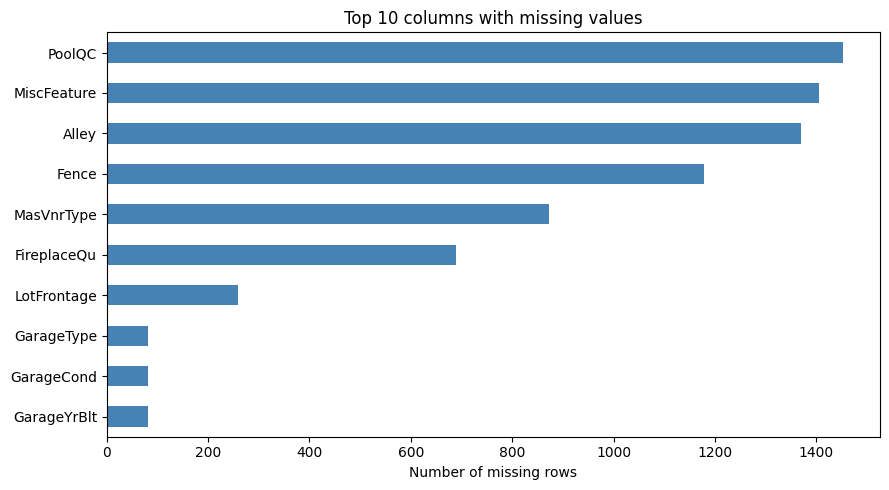

Missing values in the seven model inputs:
GrLivArea       0
OverallQual     0
YearBuilt       0
TotalBsmtSF     0
FullBath        0
BedroomAbvGr    0
GarageCars      0
dtype: int64


In [93]:
missing_counts = df.isna().sum().sort_values(ascending=False)
top_missing = missing_counts.head(10).sort_values()

plt.figure(figsize=(9, 5))
top_missing.plot(kind="barh", color="steelblue")
plt.title("Top 10 columns with missing values")
plt.xlabel("Number of missing rows")
plt.tight_layout()
plt.show()

print("Missing values in the seven model inputs:")
print(df[features].isna().sum())

**Missing-data observation.** Several original columns contain many missing
entries, including PoolQC, MiscFeature, Alley, and Fence. Some missing entries
may indicate that a feature is absent rather than that a measurement was
forgotten. All seven inputs selected for this prototype have zero missing
values in the labelled dataset, so the model training does not impute them.
At prediction time, missing information in a user's description is treated
differently: the estimate is blocked until the value is clarified.

In [94]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

X = df[features]
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

linear_model = LinearRegression()
forest_model = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

linear_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

# Same fitted Linear Regression model; explicit calculation avoids
# a NumPy matmul warning on this Mac.
linear_predictions = (
    np.einsum("ij,j->i", X_test.to_numpy(dtype=float), linear_model.coef_)
    + linear_model.intercept_
)
forest_predictions = forest_model.predict(X_test)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_predictions))
test_mean_price = y_test.mean()

print(f"Linear Regression RMSE: ${linear_rmse:,.0f}")
print(f"Random Forest RMSE: ${forest_rmse:,.0f}")
print(f"Test-set mean sale price: ${test_mean_price:,.0f}")
print(f"Training homes: {len(X_train)}; test homes: {len(X_test)}")
print("All predictions finite:",
      np.isfinite(linear_predictions).all()
      and np.isfinite(forest_predictions).all())

Linear Regression RMSE: $38,999
Random Forest RMSE: $29,941
Test-set mean sale price: $178,840
Training homes: 1168; test homes: 292
All predictions finite: True


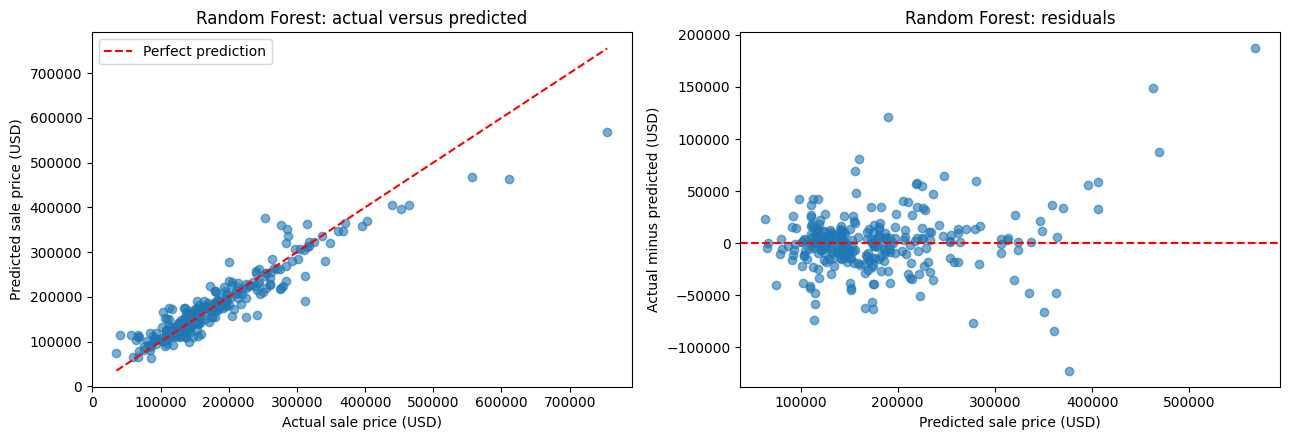

In [95]:
residuals = y_test.to_numpy() - forest_predictions
plot_min = min(y_test.min(), forest_predictions.min())
plot_max = max(y_test.max(), forest_predictions.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_test, forest_predictions, alpha=0.6)
axes[0].plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    color="red",
    linestyle="--",
    label="Perfect prediction",
)
axes[0].set_title("Random Forest: actual versus predicted")
axes[0].set_xlabel("Actual sale price (USD)")
axes[0].set_ylabel("Predicted sale price (USD)")
axes[0].legend()

axes[1].scatter(forest_predictions, residuals, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Random Forest: residuals")
axes[1].set_xlabel("Predicted sale price (USD)")
axes[1].set_ylabel("Actual minus predicted (USD)")

plt.tight_layout()
plt.show()

**Error analysis.** Many held-out predictions lie near the perfect-prediction
line, but several high-priced homes show much larger errors. In particular,
one sale near $750,000 is substantially underpredicted. Residuals are more
spread out for expensive homes, so the overall RMSE should not be interpreted
as an error guarantee for an individual property. The prototype should show
an approximate estimate and its historical test error, rather than imply
precise valuation.

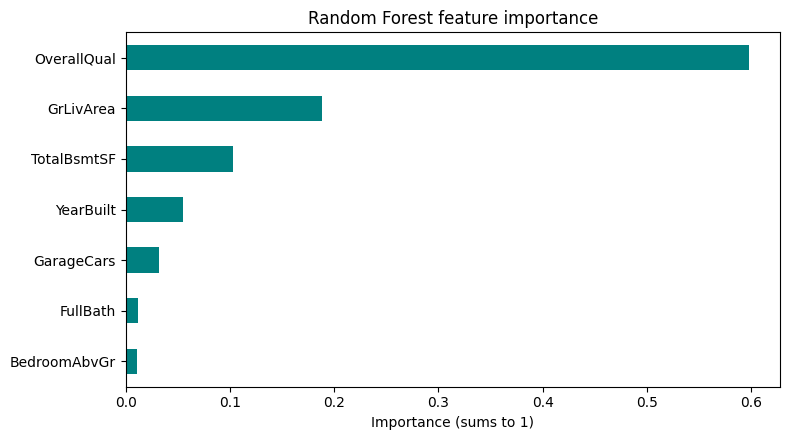

OverallQual     0.598
GrLivArea       0.189
TotalBsmtSF     0.103
YearBuilt       0.055
GarageCars      0.032
FullBath        0.012
BedroomAbvGr    0.011
dtype: float64


In [96]:
importance = pd.Series(
    forest_model.feature_importances_,
    index=features,
).sort_values()

plt.figure(figsize=(8, 4.5))
importance.plot(kind="barh", color="teal")
plt.title("Random Forest feature importance")
plt.xlabel("Importance (sums to 1)")
plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False).round(3))

### Feature importance and input trade-off

OverallQual has the highest Random Forest feature importance (0.598), followed by GrLivArea (0.189) and TotalBsmtSF (0.103). These values describe how this fitted model uses the inputs; they do not measure causal effects or the percentage of a home's price explained by each feature.

This creates a usability trade-off. OverallQual is a 1–10 rating in the training data, but a user may not know that rating for their own home. The language model must not invent it from vague words such as "nice." If the rating is missing, the estimator asks for clarification instead of showing a potentially misleading price.

In [97]:
summary = df[features].describe().loc[["min", "25%", "50%", "75%", "max"]]
display(summary.T.round(1))

,min,25%,50%,75%,max
GrLivArea,334.0,1129.5,1464.0,1776.8,5642.0
OverallQual,1.0,5.0,6.0,7.0,10.0
YearBuilt,1872.0,1954.0,1973.0,2000.0,2010.0
TotalBsmtSF,0.0,795.8,991.5,1298.2,6110.0
FullBath,0.0,1.0,2.0,2.0,3.0
BedroomAbvGr,0.0,2.0,3.0,3.0,8.0
GarageCars,0.0,1.0,2.0,2.0,4.0


In [98]:
import os
from dotenv import load_dotenv

load_dotenv(".env")
api_key = os.getenv("OPENROUTER_API_KEY")

print("OpenRouter key loaded:", bool(api_key))

OpenRouter key loaded: True


In [99]:
import json
import requests

description = """这是一栋1998年建成的住宅，整体质量评分为6分（满分10分）。
地上居住面积约150平方米，有3间卧室和2间完整浴室。
地下室面积约70平方米，车库可以停1辆车。"""

prompt = """
Extract these house features from the user's description:
GrLivArea, OverallQual, YearBuilt, TotalBsmtSF,
FullBath, BedroomAbvGr, GarageCars.

Return only a JSON object with exactly these seven keys.
Use numbers, not strings. Use null when a value is not stated.
GrLivArea and TotalBsmtSF must be in square feet.
Convert square metres to square feet using 1 square metre = 10.7639 square feet.
Do not guess missing values or infer quality from vague words.
If the description gives conflicting values, use null for that field.
"""

response = requests.post(
    "https://openrouter.ai/api/v1/chat/completions",
    headers={"Authorization": f"Bearer {api_key}"},
    json={
        "model": "openai/gpt-4.1-mini",
        "messages": [
            {"role": "system", "content": prompt},
            {"role": "user", "content": description},
        ],
        "response_format": {"type": "json_object"},
        "temperature": 0,
    },
    timeout=30,
)

response.raise_for_status()
result = response.json()
extracted = json.loads(result["choices"][0]["message"]["content"])

print("Extracted features:")
print(json.dumps(extracted, indent=2, ensure_ascii=False))
print("Usage:", result.get("usage"))

Extracted features:
{
  "GrLivArea": 1614.59,
  "OverallQual": 6,
  "YearBuilt": 1998,
  "TotalBsmtSF": 753.47,
  "FullBath": 2,
  "BedroomAbvGr": 3,
  "GarageCars": 1
}
Usage: {'prompt_tokens': 190, 'completion_tokens': 70, 'total_tokens': 260, 'cost': 0.000188, 'is_byok': False, 'prompt_tokens_details': {'cached_tokens': 0, 'cache_write_tokens': 0, 'audio_tokens': 0, 'video_tokens': 0}, 'cost_details': {'upstream_inference_cost': 0.000188, 'upstream_inference_prompt_cost': 7.6e-05, 'upstream_inference_completions_cost': 0.000112}, 'completion_tokens_details': {'reasoning_tokens': 0, 'image_tokens': 0, 'audio_tokens': 0}}


In [100]:
missing = [name for name in features if extracted.get(name) is None]
if missing:
    raise ValueError(f"Missing or conflicting features: {missing}")

for name in features:
    value = extracted[name]
    lower = df[name].min()
    upper = df[name].max()
    if not isinstance(value, (int, float)) or not lower <= value <= upper:
        raise ValueError(
            f"{name} = {value} is outside the training-data range "
            f"({lower} to {upper}). Please check the description."
        )

print("Please confirm these extracted features:")
for name in features:
    print(f"  {name}: {extracted[name]}")

confirmation = "yes"  # Case 2: I reviewed the seven extracted values above
if confirmation.strip().lower() == "yes":
    property_data = pd.DataFrame([extracted], columns=features)
    estimated_price = forest_model.predict(property_data)[0]
    print(f"Estimated sale price: approximately ${estimated_price:,.0f}")
    print("Based on historical Ames housing data; not a current market valuation.")
else:
    print("Estimate cancelled. Correct the description before trying again.")

Please confirm these extracted features:
  GrLivArea: 1614.59
  OverallQual: 6
  YearBuilt: 1998
  TotalBsmtSF: 753.47
  FullBath: 2
  BedroomAbvGr: 3
  GarageCars: 1
Estimated sale price: approximately $159,719
Based on historical Ames housing data; not a current market valuation.


## Initial end-to-end tests

| Case | Description | Extraction check | Estimated price | OpenRouter cost |
|---|---|---|---:|---:|
| 1 | English description, areas in square feet | All 7 fields correct | $194,164 | $0.0001784 |
| 2 | Chinese description, areas in square metres | All 7 fields correct; 150 m² → 1614.59 ft² and 70 m² → 753.47 ft² | $159,719 | $0.000188 |

In [101]:
def extract_features(description):
    response = requests.post(
        "https://openrouter.ai/api/v1/chat/completions",
        headers={"Authorization": f"Bearer {api_key}"},
        json={
            "model": "openai/gpt-4.1-mini",
            "messages": [
                {"role": "system", "content": prompt},
                {"role": "user", "content": description},
            ],
            "response_format": {"type": "json_object"},
            "temperature": 0,
        },
        timeout=30,
    )
    response.raise_for_status()

    result = response.json()
    values = json.loads(result["choices"][0]["message"]["content"])
    usage = result.get("usage", {})
    return values, usage

In [106]:
def check_and_estimate(values):
    missing = [name for name in features if values.get(name) is None]
    if missing:
        return {
            "status": "blocked",
            "reason": f"Missing or conflicting fields: {missing}",
            "estimated_price": None,
        }

    for name in features:
        value = values[name]
        lower, upper = df[name].min(), df[name].max()

        if (
            isinstance(value, bool)
            or not isinstance(value, (int, float))
            or not lower <= value <= upper
        ):
            return {
                "status": "blocked",
                "reason": (
                    f"{name}={value} is invalid or outside "
                    f"the training range [{lower}, {upper}]"
                ),
                "estimated_price": None,
            }

    property_data = pd.DataFrame([values], columns=features)
    price = forest_model.predict(property_data)[0]

    return {
        "status": "estimated",
        "reason": None,
        "estimated_price": round(float(price)),
    }

print("Case 3:", check_and_estimate(case_3_features))
print("Case 4:", check_and_estimate(case_4_features))

Case 3: {'status': 'blocked', 'reason': "Missing or conflicting fields: ['OverallQual']", 'estimated_price': None}
Case 4: {'status': 'blocked', 'reason': "Missing or conflicting fields: ['YearBuilt']", 'estimated_price': None}


In [113]:
# ============================================================
# Initial End-to-End Tests
# ============================================================

# Case 1 — English description in square feet
# Keep this case unchanged as the original successful baseline.
case_1_description = (
    "A house built in 2003 with 1,710 square feet of above-ground living area, "
    "three bedrooms, two full bathrooms, an 856-square-foot basement, "
    "a two-car garage, and overall quality rated 7 out of 10."
)

case_1_features, case_1_usage = extract_features(case_1_description)

print("Case 1 — English description in square feet")
print(json.dumps(case_1_features, indent=2))
print("Cost (USD):", case_1_usage.get("cost"))

case_1_result = check_and_estimate(case_1_features)
print("System result:", case_1_result)


# Case 2 — Larger valid house
case_2_description = (
    "A house built in 2008 with 2,400 square feet of above-ground living area, "
    "four bedrooms, three full bathrooms, a 1,200-square-foot basement, "
    "a two-car garage, and overall quality rated 9 out of 10."
)

case_2_features, case_2_usage = extract_features(case_2_description)

print("\nCase 2 — Larger valid house")
print(json.dumps(case_2_features, indent=2))
print("Cost (USD):", case_2_usage.get("cost"))

case_2_result = check_and_estimate(case_2_features)
print("System result:", case_2_result)


# Case 3 — Missing required fields
# OverallQual, TotalBsmtSF and GarageCars are intentionally omitted.
case_3_description = """A house built in 1998 with 1,600 square feet of
above-ground living area, three bedrooms, and two full bathrooms.
The description does not provide the overall quality score, basement area,
or garage capacity."""

case_3_features, case_3_usage = extract_features(case_3_description)

print("\nCase 3 — missing required fields")
print(json.dumps(case_3_features, indent=2, ensure_ascii=False))
print("Cost (USD):", case_3_usage.get("cost"))

case_3_result = check_and_estimate(case_3_features)
print("System result:", case_3_result)


# Case 4 — Conflicting garage capacity
# The description intentionally gives two different garage capacities.
case_4_description = """A house built in 2003 with 1,710 square feet of
above-ground living area, overall quality 7 out of 10, three bedrooms,
two full bathrooms, an 856-square-foot basement, and a two-car garage.
The listing also says that the garage can accommodate four cars."""

case_4_features, case_4_usage = extract_features(case_4_description)

print("\nCase 4 — conflicting garage capacity")
print(json.dumps(case_4_features, indent=2))
print("Cost (USD):", case_4_usage.get("cost"))

case_4_result = check_and_estimate(case_4_features)
print("System result:", case_4_result)


# Case 5 — Outside training-data range
# Keep this case unchanged as the original validation case.
case_5_description = """A house built in 2022 with 1,600 square feet of
above-ground living area, overall quality 7 out of 10, three bedrooms,
two full bathrooms, a 900-square-foot basement, and a two-car garage."""

case_5_features, case_5_usage = extract_features(case_5_description)
case_5_result = check_and_estimate(case_5_features)

print("\nCase 5 — outside training-data range")
print("Extracted:", case_5_features)
print("System result:", case_5_result)
print("Cost (USD):", case_5_usage.get("cost"))


# Case 6 — Chinese description in square metres
case_6_description = """这套房子建于2003年，地上居住面积约159平方米，
整体质量评分7分，共有3间卧室、2个完整卫生间，
地下室面积约80平方米，并带有2车位车库。"""

case_6_features, case_6_usage = extract_features(case_6_description)

print("\nCase 6 — Chinese description in square metres")
print(json.dumps(case_6_features, indent=2, ensure_ascii=False))
print("Cost (USD):", case_6_usage.get("cost"))

case_6_result = check_and_estimate(case_6_features)
print("System result:", case_6_result)


# ============================================================
# Evaluation Summary
# ============================================================

test_results = pd.DataFrame([
    {
        "Case": 1,
        "Scenario": "English; square feet; complete",
        "Extraction": "7/7 features extracted",
        "System result": f"Estimated ${case_1_result['estimated_price']:,}"
            if case_1_result["status"] == "estimated"
            else f"Blocked; {case_1_result['reason']}",
        "API cost (USD)": case_1_usage.get("cost"),
    },
    {
        "Case": 2,
        "Scenario": "English; larger valid house; complete",
        "Extraction": "7/7 features extracted",
        "System result": f"Estimated ${case_2_result['estimated_price']:,}"
            if case_2_result["status"] == "estimated"
            else f"Blocked; {case_2_result['reason']}",
        "API cost (USD)": case_2_usage.get("cost"),
    },
    {
        "Case": 3,
        "Scenario": "Missing required fields",
        "Extraction": "OverallQual, TotalBsmtSF and GarageCars expected as null",
        "System result": "Blocked; required fields are missing"
            if case_3_result["status"] == "blocked"
            else f"Estimated ${case_3_result['estimated_price']:,}",
        "API cost (USD)": case_3_usage.get("cost"),
    },
    {
        "Case": 4,
        "Scenario": "Conflicting garage capacity",
        "Extraction": "GarageCars expected as null",
        "System result": "Blocked; garage capacity must be clarified"
            if case_4_result["status"] == "blocked"
            else f"Estimated ${case_4_result['estimated_price']:,}",
        "API cost (USD)": case_4_usage.get("cost"),
    },
    {
        "Case": 5,
        "Scenario": "Construction year outside training range",
        "Extraction": "YearBuilt = 2022",
        "System result": "Blocked; year exceeds 2010"
            if case_5_result["status"] == "blocked"
            else f"Estimated ${case_5_result['estimated_price']:,}",
        "API cost (USD)": case_5_usage.get("cost"),
    },
    {
        "Case": 6,
        "Scenario": "Chinese; square metres; complete",
        "Extraction": "7/7 features extracted; units converted",
        "System result": f"Estimated ${case_6_result['estimated_price']:,}"
            if case_6_result["status"] == "estimated"
            else f"Blocked; {case_6_result['reason']}",
        "API cost (USD)": case_6_usage.get("cost"),
    },
])

display(test_results)

print(
    "Mean API cost per attempt: "
    f"${test_results['API cost (USD)'].mean():.7f}"
)

Case 1 — English description in square feet
{
  "GrLivArea": 1710,
  "OverallQual": 7,
  "YearBuilt": 2003,
  "TotalBsmtSF": 856,
  "FullBath": 2,
  "BedroomAbvGr": 3,
  "GarageCars": 2
}
Cost (USD): 0.0001784
System result: {'status': 'estimated', 'reason': None, 'estimated_price': 194164}

Case 2 — Larger valid house
{
  "GrLivArea": 2400,
  "OverallQual": 9,
  "YearBuilt": 2008,
  "TotalBsmtSF": 1200,
  "FullBath": 3,
  "BedroomAbvGr": 4,
  "GarageCars": 2
}
Cost (USD): 0.0001808
System result: {'status': 'estimated', 'reason': None, 'estimated_price': 332000}

Case 3 — missing required fields
{
  "GrLivArea": 1600,
  "OverallQual": null,
  "YearBuilt": 1998,
  "TotalBsmtSF": null,
  "FullBath": 2,
  "BedroomAbvGr": 3,
  "GarageCars": null
}
Cost (USD): 0.000172
System result: {'status': 'blocked', 'reason': "Missing or conflicting fields: ['OverallQual', 'TotalBsmtSF', 'GarageCars']", 'estimated_price': None}

Case 4 — conflicting garage capacity
{
  "GrLivArea": 1710,
  "OverallQu

,Case,Scenario,Extraction,System result,API cost (USD)
0,1,English; square feet; complete,7/7 features extracted,"Estimated $194,164",0.000178
1,2,English; larger valid house; complete,7/7 features extracted,"Estimated $332,000",0.000181
2,3,Missing required fields,"OverallQual, TotalBsmtSF and GarageCars expect...",Blocked; required fields are missing,0.000172
3,4,Conflicting garage capacity,GarageCars expected as null,Blocked; garage capacity must be clarified,0.000182
4,5,Construction year outside training range,YearBuilt = 2022,Blocked; year exceeds 2010,0.000178
5,6,Chinese; square metres; complete,7/7 features extracted; units converted,"Estimated $195,170",0.000186


Mean API cost per attempt: $0.0001795


## Design choices and trade-offs

**Build versus rent.** I build the data preparation, Linear Regression baseline,
Random Forest regressor, validation rules, and evaluation in Python. I rent a
foundation model through OpenRouter only to turn a free-text property description
into seven structured features. This avoids training a language model for a small
prototype, but introduces an external API dependency and a charge for every
extraction attempt.

**Why two prediction models?** Linear Regression is a simple, interpretable
baseline. Random Forest can capture non-linear relationships, but is harder to
explain. Both use the same 80/20 split (random_state=42). On the 292 held-out
homes, Linear Regression has RMSE $38,999 and Random Forest has RMSE $29,941,
beside a mean sale price of $178,840. I use Random Forest for the prototype
because its held-out RMSE is lower.

**Prompting and validation.** The prompt requests exactly seven numeric fields
in JSON, converts square metres to square feet, returns null for missing or
conflicting information, and prohibits guessing. Local Python rules then block
missing, invalid, or out-of-range values before price prediction. The extracted
values should be reviewed by the user before an estimate is accepted.

**Cost and reliability.** Across five actual OpenRouter requests, the mean
reported API cost was about $0.0001795 per attempt. This is a small prototype
sample, not a guaranteed future price. Two complete descriptions produced
estimates; missing quality, conflicting years, and a year outside the training
range were blocked. Blocking uncertain inputs reduces misleading estimates,
but also means some users must provide more information.

**Limitations.** The Kaggle data represents historical housing sales in Ames,
Iowa; it does not provide a current valuation for Singapore or other markets.
The training data's newest construction year is 2010. RMSE measures prediction
error on held-out historical rows with known features; it does not include
errors caused by extracting features from real user descriptions. This
prototype is decision support, not a professional appraisal.

In [111]:
# Demo: replace this text with a description of a house you want to estimate.
user_description = """A house built in 2003 with 1,710 square feet of
above-ground living area, overall quality 7 out of 10, three bedrooms,
two full bathrooms, an 856-square-foot basement, and a two-car garage."""

user_features, user_usage = extract_features(user_description)

print("Please review the seven extracted values:")
for name in features:
    print(f"  {name}: {user_features.get(name)}")

print("OpenRouter cost (USD):", user_usage.get("cost"))

Please review the seven extracted values:
  GrLivArea: 1710
  OverallQual: 7
  YearBuilt: 2003
  TotalBsmtSF: 856
  FullBath: 2
  BedroomAbvGr: 3
  GarageCars: 2
OpenRouter cost (USD): 0.0001784


In [112]:
# Set to True only after checking all seven values printed above.
user_confirmed = True

if not user_confirmed:
    print("Estimate cancelled. Correct the description and try again.")
else:
    user_result = check_and_estimate(user_features)

    if user_result["status"] == "blocked":
        print("Estimate blocked:", user_result["reason"])
    else:
        print(
            f"Estimated sale price: approximately "
            f"${user_result['estimated_price']:,}"
        )
        print(f"Historical test RMSE: ${forest_rmse:,.0f}")
        print(
            "Based on historical Ames sales; "
            "not a current professional valuation."
        )

Estimated sale price: approximately $194,164
Historical test RMSE: $29,941
Based on historical Ames sales; not a current professional valuation.
